# Grid search

Following tutorial: https://www.youtube.com/watch?v=HL1-mc1DvFY

In [ ]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

In [3]:
import numpy as np

Use sklearn dataset "make_regression" to generate data with n_samples and n_features. 

- Samples = rows = individual observations (e.g. a house, a person, a data point)
- Features = columns = the attributes/variables that describe each sample (e.g. size, age, income)

In our case we choose n_samples=1000 and n_features and 20. 
So X has shape (1000, 20) meaning:
- 1000 = number of samples (rows)
- 20 = number of features (columns)
- y has shape (1000,) — one target value per sample

A real-world analogy: if you're predicting house prices,
- each sample is one house
- each feature is one property of that house (size, number of rooms, age, distance to city...)
- y is the price of that house

In [ ]:
X, y = make_regression(n_samples=1000, n_features=20, noise=0.1)
X

array([[-1.49677471,  0.14265702,  0.30740626, ..., -0.07665655,
         0.39840312,  1.45158572],
       [ 1.16797014,  0.50534386, -0.52087109, ..., -0.19492943,
        -0.28366953,  1.07183067],
       [-0.17197917,  0.49492844,  0.21342185, ..., -1.17797015,
         0.98287952,  0.29890727],
       ...,
       [-1.83391863, -1.72946022,  0.4543403 , ...,  0.14444259,
         0.99135861, -0.12395168],
       [ 0.6475746 , -1.26154382, -0.65070891, ..., -0.17792294,
         0.29534822,  1.4981699 ],
       [ 0.45092994, -0.45380946,  0.56793469, ..., -0.04973793,
        -0.07929087,  0.14577766]], shape=(1000, 20))

In [5]:
y

array([   8.83714572,  106.03276513, -261.58403   ,  126.64655248,
       -718.95996121,  -47.54724774,  265.97881077,  -59.60590056,
       -228.17295094, -261.76878968,  159.75275329,  -73.06151502,
       -435.99402342,   39.95126596, -323.74220893,   77.61258092,
       -360.46504628, -347.24122505, -188.38431307,  292.21483449,
         22.98660366,  148.13909685,  682.42609715,  248.39008731,
       -124.31006919, -155.12128693, -438.76446557,   20.83387492,
       -298.95872798, -414.97860926, -222.09313554,  330.62171877,
        100.94719003, -407.22727168, -337.49085159,  -95.46836913,
         77.99564239,   56.80912723, -316.36890016, -101.1966916 ,
       -114.93104156, -180.72823584,   33.68705117,  143.30733725,
       -313.44229919,    3.84455312,  223.8512177 ,  436.7378481 ,
       -141.63663073,  140.5668238 ,  103.47702631,   39.32765085,
         77.27848737,  -87.10658117,  267.08896148,  -35.0738779 ,
         85.39162082,  -31.68131983,   89.17359937,  508.94384

In [56]:
X[:,0].shape

(1000,)

Create a plot that shows each feature vs target variable

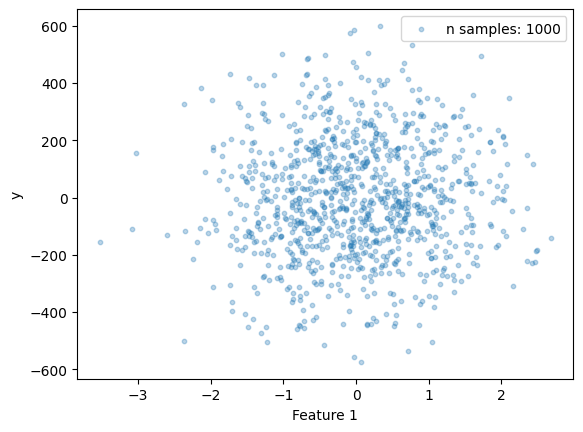

In [68]:
# plot just feature 0
plt.scatter(X[:, 0], y, alpha=0.3, s=10, label=f'n samples: {len(X[:, 0])}')  # just feature 1
plt.xlabel("Feature 1")
plt.ylabel("y")
plt.legend()
plt.show()

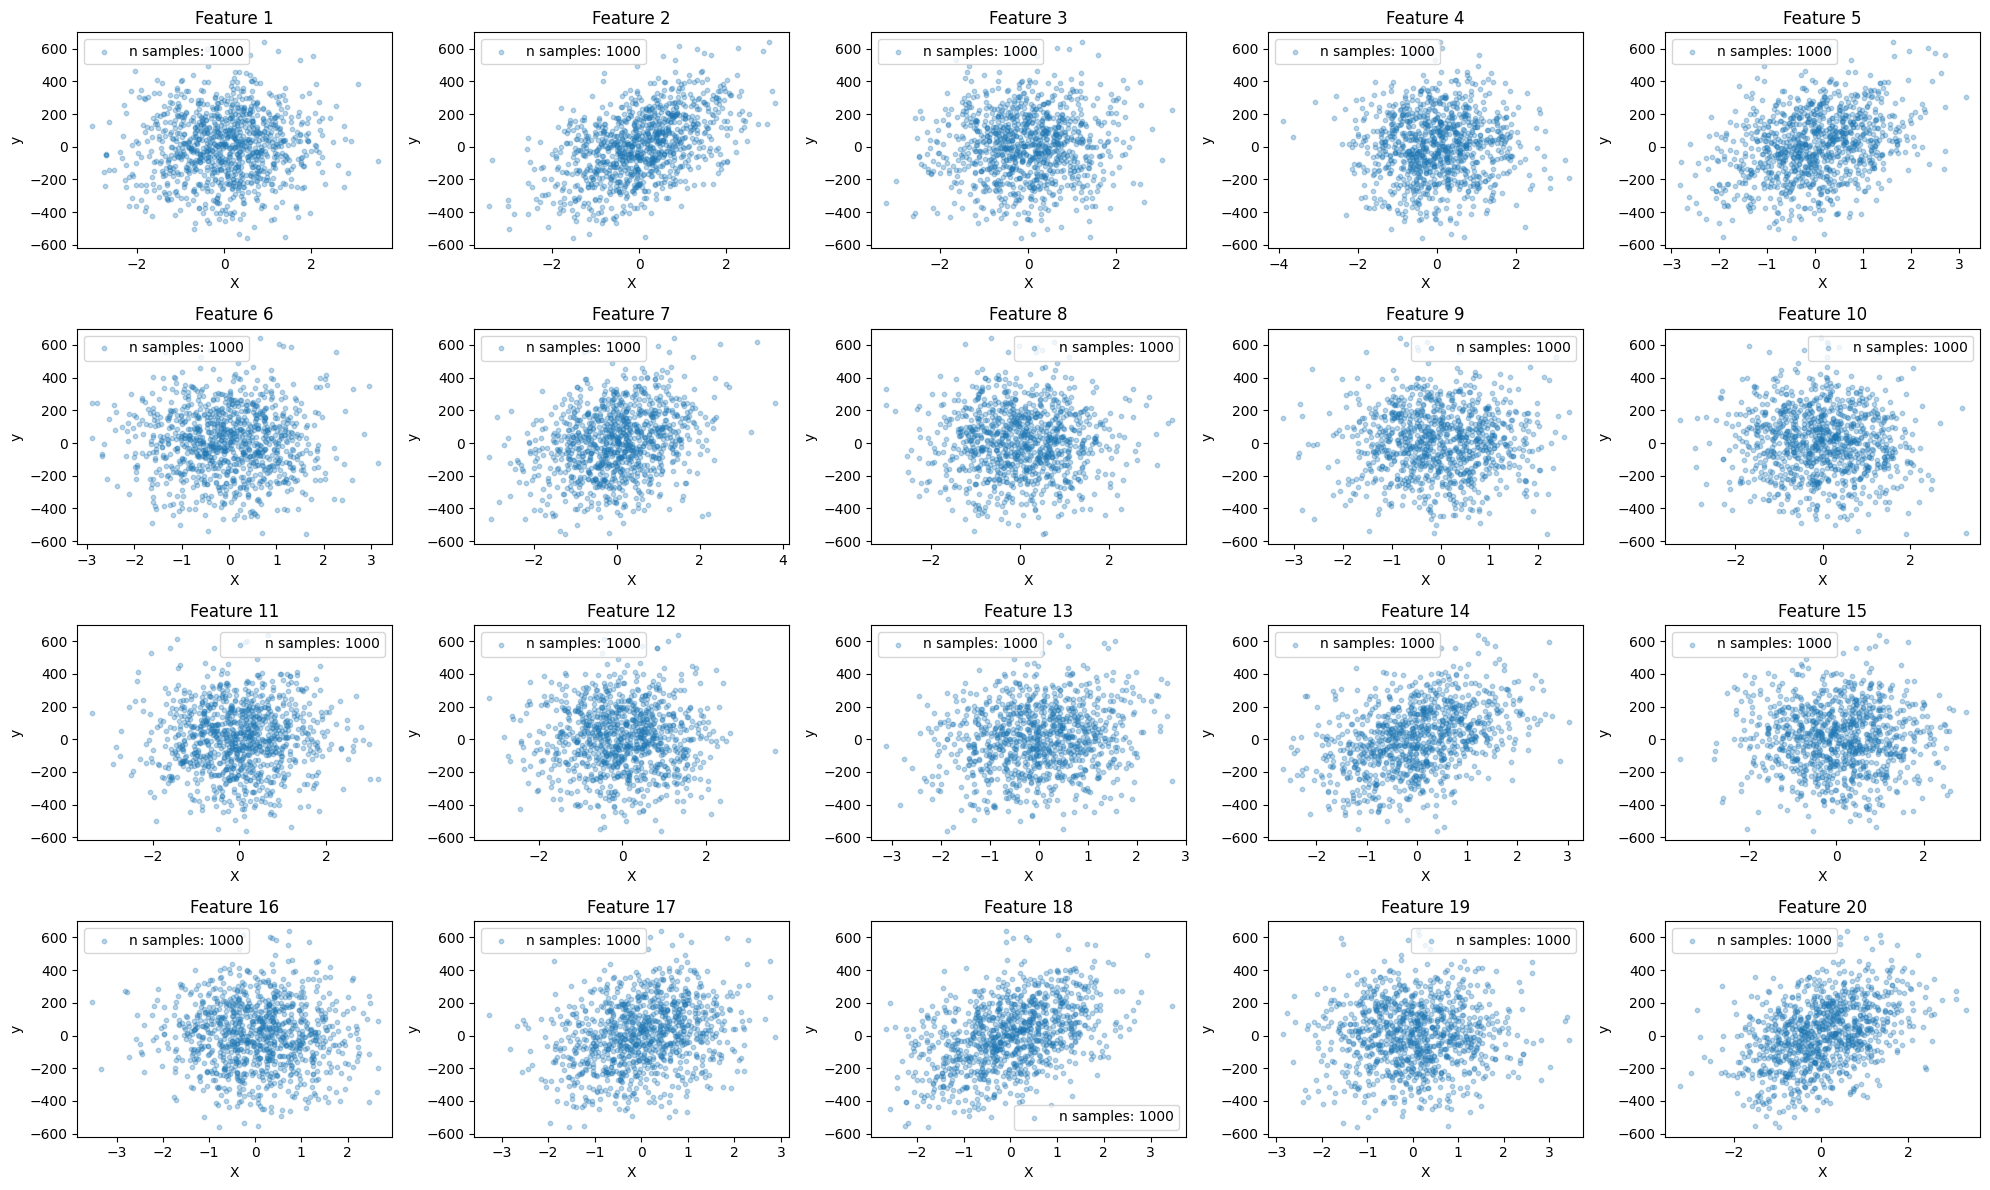

In [70]:
#plot all features

X, y = make_regression(n_samples=1000, n_features=20, noise=0.1)

fig, axes = plt.subplots(4, 5, figsize=(20, 12))
axes = axes.flatten()

for i in range(20):
    axes[i].scatter(X[:, i], y, alpha=0.3, s=10, label=f'n samples: {len(X[:, 0])}')
    axes[i].set_title(f"Feature {i+1}")
    axes[i].set_xlabel("X")
    axes[i].set_ylabel("y")
    axes[i].legend()

plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [10]:
# create Ridge regression model
from sklearn.linear_model import Ridge

In [11]:
model = Ridge()

Each model has specific parameters

In [13]:
param_grid = {
    "alpha" : [0.1, 1.0, 10.0, 100.0], #regularisation strenght
    "solver": ["auto", "svd", "lsqr"], # algorithm to solve optimization problem
}

Now, let's perform the grid search $\to$ will try all combination of param grid, and returns the best performing one.

In [ ]:
from sklearn.model_selection import GridSearchCV # CV = Cross Validation

This is where we do the hyperparameters tuning.

In [18]:
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring = "neg_mean_squared_error")

'''

cv = 5 means that algorith separates data into 5 parts, train on 4 parts and test on the remaining 1 part
scoring="neg_mean_squared_error" means that the metric for maximizing performance is neg_mean_squared_error -> lower mean squared error means better performance

'''

'\n\ncv = 5 means that algorith separates data into 5 parts, train on 4 parts and test on the remaining 1 part\nscoring="neg_mean_squared_error" means that the metric for maximizing performance is neg_mean_squared_error -> lower mean squared error means better performance\n\n'

In [19]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.1, 1.0, ...], 'solver': ['auto', 'svd', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : 

Check best hyperparameters found, and use this to evaluate the model. 

In [20]:
best_params = grid_search.best_params_
best_params

{'alpha': 0.1, 'solver': 'lsqr'}

We see the lowest value has been picked, so we can lower low threshold of param grid

In [35]:
param_grid = {
    "alpha" : [1e-30, 0.01, 0.1, 1.0], #regularisation strenght
    "solver": ["auto", "svd", "lsqr"], # algorithm to solve optimization problem
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring = "neg_mean_squared_error")

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [1e-30, 0.01, ...], 'solver': ['auto', 'svd', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3

In [29]:
best_params = grid_search.best_params_
best_params

{'alpha': 1e-30, 'solver': 'svd'}

Save model which has best estimator

In [30]:
best_model = grid_search.best_estimator_

In [31]:
from sklearn.metrics import mean_squared_error

In [32]:
y_pred = best_model.predict(X_test)
y_pred

array([ 360.45553437,  126.07246586,  -93.13735665,  323.35250765,
        300.67248295,  -42.28097936,  108.31557699, -261.5761912 ,
       -511.77453655,   60.42346996, -275.82863519,  223.58510572,
        308.42733597,  -99.76211844,  -86.50937732, -339.38078995,
        568.53800592,   25.01887201,  186.69886796,   23.93408761,
        403.69829636, -185.83855085, -142.26514148,  -27.41027853,
       -127.15145922,  -16.28205789,  528.87332795, -415.00616405,
         53.66985422,   19.86642741,  -81.04583637,  197.25387336,
        514.8763934 ,  -33.4408243 ,  110.68669255,  -16.51708954,
       -302.9808434 ,   37.08601371,  418.89846599, -485.03883094,
        -33.22683555, -118.93162207,  138.92256501, -179.59065228,
        -55.87621007, -126.272611  ,  126.68094116,  -67.32761917,
         50.44651439, -199.37330125,  187.28634195,   66.15443079,
        353.79350768,  391.92055113,   78.51869197,  136.94809316,
         10.54480824,  682.56187612,  -89.13047435,   41.33891

Compare these values with actual y values. We use Mean Squared Error (MSE), defined as

$ MSE = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$

n = number of features (in this case n=200)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
mse 

0.011924041950738134

The fact that this value is good or bad completely depends on definition and problem

In [59]:
y_pred.shape

(200,)

In [60]:
y.shape

(1000,)

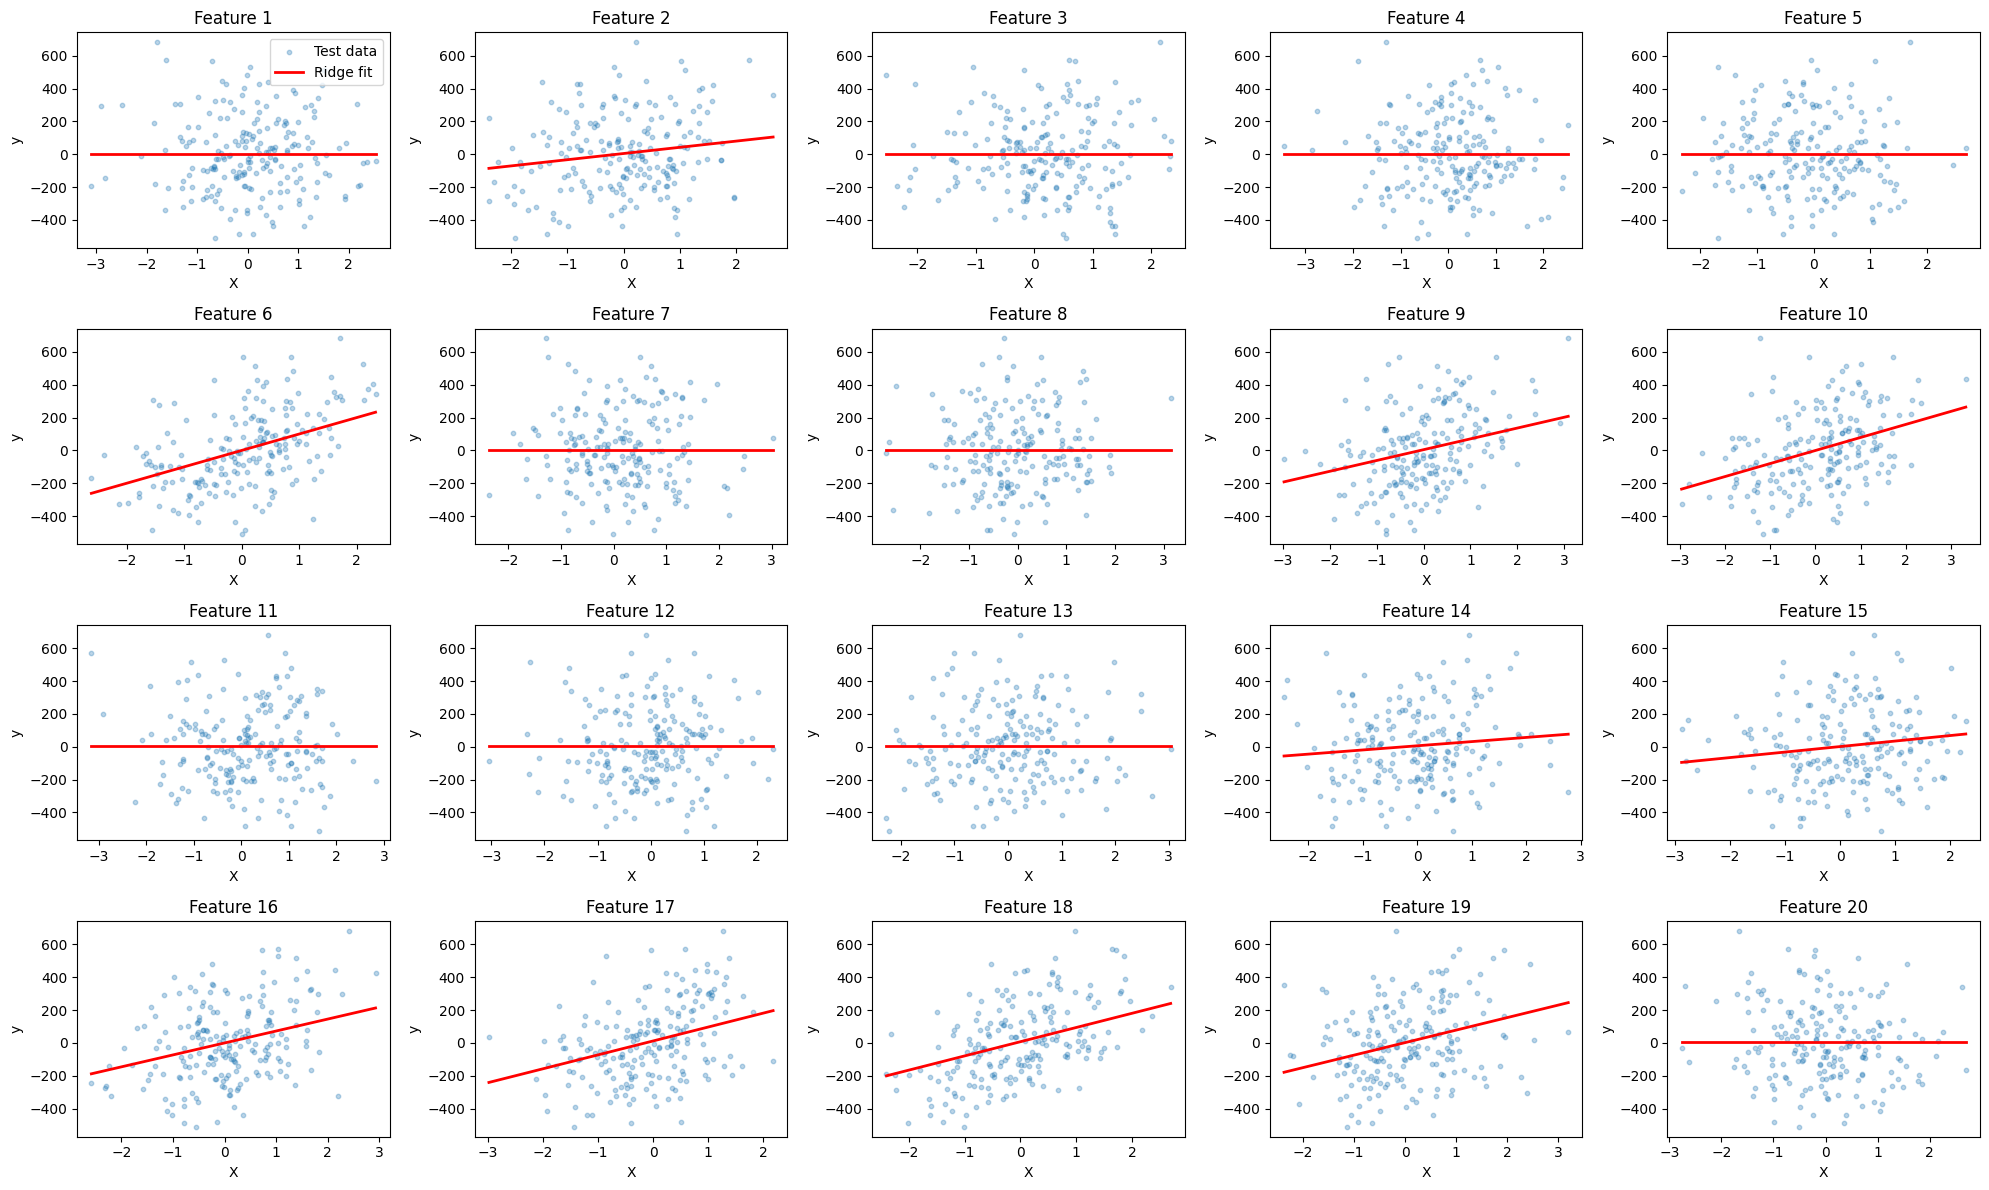

In [61]:
fig, axes = plt.subplots(4, 5, figsize=(20, 12))
axes = axes.flatten()

X_mean = X_test.mean(axis=0)  # baseline: mean of all features

for i in range(20):
    x_col = X_test[:, i]

    # Build a synthetic grid varying only feature i, others fixed at mean
    x_range = np.linspace(x_col.min(), x_col.max(), 100)
    X_line = np.tile(X_mean, (100, 1))  # repeat mean row 100 times
    X_line[:, i] = x_range              # vary only feature i

    y_line = best_model.predict(X_line)

    axes[i].scatter(x_col, y_test, alpha=0.3, s=10, label="Test data")
    axes[i].plot(x_range, y_line, color="red", linewidth=2, label="Ridge fit")
    axes[i].set_title(f"Feature {i+1}")
    axes[i].set_xlabel("X")
    axes[i].set_ylabel("y")

axes[0].legend()
plt.tight_layout()
plt.show()

I wanna see the "per sample error".

In [62]:
# Per-sample squared errors
residuals = y_test - y_pred               # raw error per sample
squared_errors = residuals ** 2           # squared error per sample

# These are all equivalent to mse
mse = mean_squared_error(y_test, y_pred)  # single value (mean)
mse = squared_errors.mean()               # same thing
mse = (residuals ** 2).mean()             # same thing

# Useful things to look at alongside MSE
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {mse**0.5:.4f}")           # same unit as y
print(f"MAE:  {abs(residuals).mean():.4f}")  # less sensitive to outliers

MSE:  0.0119
RMSE: 0.1092
MAE:  0.0862


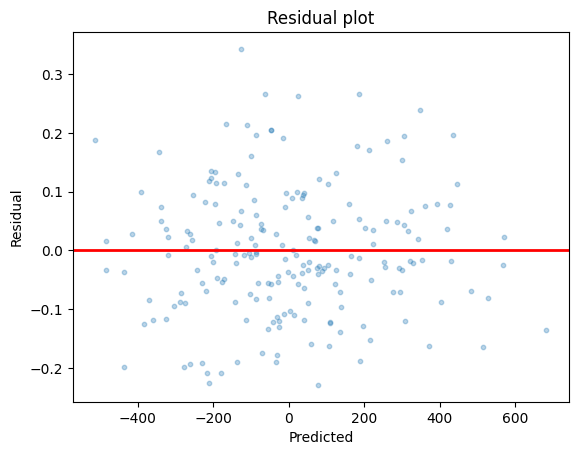

In [63]:
plt.scatter(y_pred, residuals, alpha=0.3, s=10)
plt.axhline(0, color="red", linewidth=2)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual plot")
plt.show()

In [65]:
residuals.shape

(200,)